# Manufacturing Productivity Analysis using OEE

This notebook presents a data-driven approach to evaluating and improving industrial performance through the **Overall Equipment Effectiveness (OEE)** framework. OEE is a standard metric used globally to identify the percentage of manufacturing time that is truly productive.

## Objective
The primary goal of this analysis is to transform raw manufacturing data across multiple production lines and shifts—into actionable strategic insights. By decomposing OEE into its three core components, we can pinpoint whether productivity losses are driven by mechanical downtime, sub-optimal cycle times, or quality defects.

## Key Analytical Components
* **Data Synthesis:** Utilizing advanced probability distributions (Beta and Normal) to simulate 10,000+ realistic observations of plant activity, including line-specific behaviors and shift-based patterns.
* **Statistical Validation:** Applying **One-way ANOVA** to determine if performance variations between Morning, Afternoon, and Night shifts are statistically significant or merely due to random noise.
* **Root Cause Identification:** Segmenting "Poor Performance" events to identify the primary drivers of inefficiency.
* **Financial Impact Modeling:** Calculating the potential annual revenue gain of reaching a "World Class" OEE benchmark of 85%.

## The Tech Stack
This project leverages the standard Python data science ecosystem:
* **Pandas & NumPy** for high-performance data manipulation.
* **Matplotlib & Seaborn** for statistical data visualization.
* **Scipy Stats** for rigorous hypothesis testing.

Through this analysis, we aim to provide manufacturing leadership with a clear roadmap for equipment modernization, shift structure optimization, and predictive maintenance scheduling.

## Import Required Libraries and Setup
I'm importing essential data science libraries. Pandas handles data manipulation, numpy provides numerical operations, matplotlib and seaborn create visualizations. The datetime module helps create time-based data, while scipy supports statistical analysis. I'm suppressing warnings to keep the output clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported succesfully!")

Libraries imported succesfully!


## Generate Dataset
I created a realistic manufacturing dataset with 10,000 observations representing hourly production records. I intentionally designed 5 production lines with significantly different baseline capabilities (Line D being the best at ~87% OEE, Line E being the worst at ~60% OEE). I incorporated real-world factors like weekend effects, shift differentials, and random noise to simulate actual plant conditions.

In [13]:
# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
n_observations = 10000
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

# Define production lines with different baseline performance levels
production_lines = {
    'Line_A': {'availability': 0.92, 'performance': 0.88, 'quality': 0.95, 'shift_hours': 16},
    'Line_B': {'availability': 0.85, 'performance': 0.82, 'quality': 0.91, 'shift_hours': 16},
    'Line_C': {'availability': 0.78, 'performance': 0.75, 'quality': 0.88, 'shift_hours': 16},
    'Line_D': {'availability': 0.95, 'performance': 0.94, 'quality': 0.97, 'shift_hours': 24},
    'Line_E': {'availability': 0.70, 'performance': 0.68, 'quality': 0.85, 'shift_hours': 8}
}

# Generate timestamps
timestamps = [start_date + timedelta(hours=x) for x in range(n_observations)]

# Initialize lists to store data
data = {
    'timestamp': [],
    'line_id': [],
    'planned_production_time': [],
    'downtime_minutes': [],
    'ideal_cycle_time': [],
    'total_units_produced': [],
    'defective_units': []
}

# Generate data for each observation
for i in range(n_observations):
    # Randomly select a production line
    line = np.random.choice(list(production_lines.keys()), p=[0.25, 0.2, 0.2, 0.25, 0.1])
    line_params = production_lines[line]
    
    # Add time-based effects (seasonality, day of week effects)
    current_time = timestamps[i]
    hour = current_time.hour
    day_of_week = current_time.weekday()
    month = current_time.month
    
    # Weekend effect (reduced performance)
    weekend_effect = 0.85 if day_of_week >= 5 else 1.0
    
    # Shift effect
    if hour < 6 or hour >= 22:
        shift_effect = 0.90  # Night shift slightly lower performance
    else:
        shift_effect = 1.0
    
    # Calculate actual metrics with noise and effects
    availability = line_params['availability'] * weekend_effect * shift_effect
    availability += np.random.normal(0, 0.03)  # Add noise
    availability = np.clip(availability, 0.5, 0.99)
    
    performance = line_params['performance'] * weekend_effect * shift_effect
    performance += np.random.normal(0, 0.04)
    performance = np.clip(performance, 0.5, 0.98)
    
    quality = line_params['quality'] * weekend_effect
    quality += np.random.normal(0, 0.02)
    quality = np.clip(quality, 0.75, 0.99)
    
    # Calculate derived metrics
    planned_time = line_params['shift_hours'] * 60  # in minutes
    downtime = planned_time * (1 - availability) * np.random.uniform(0.8, 1.2)
    operating_time = planned_time - downtime
    
    # Calculate production metrics
    ideal_cycle_time = np.random.uniform(0.5, 2.0)  # minutes per unit
    theoretical_output = operating_time / ideal_cycle_time
    actual_output = theoretical_output * performance * np.random.uniform(0.9, 1.1)
    total_units = int(actual_output)
    defective_units = int(total_units * (1 - quality))
    
    # Store data
    data['timestamp'].append(current_time)
    data['line_id'].append(line)
    data['planned_production_time'].append(planned_time)
    data['downtime_minutes'].append(downtime)
    data['ideal_cycle_time'].append(ideal_cycle_time)
    data['total_units_produced'].append(total_units)
    data['defective_units'].append(defective_units)

# Create DataFrame
df = pd.DataFrame(data)

# Calculate OEE components
df['operating_time'] = df['planned_production_time'] - df['downtime_minutes']
df['availability_rate'] = df['operating_time'] / df['planned_production_time']
df['theoretical_units'] = df['operating_time'] / df['ideal_cycle_time']
df['performance_rate'] = df['total_units_produced'] / df['theoretical_units']
df['quality_rate'] = 1 - (df['defective_units'] / df['total_units_produced'])
df['oee'] = df['availability_rate'] * df['performance_rate'] * df['quality_rate']

# Add additional features for analysis
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# Use unique labels to satisfy pd.cut()
df['shift'] = pd.cut(df['hour'], bins=[0, 6, 14, 22, 24], 
                      labels=['Night_Early', 'Morning', 'Afternoon', 'Night_Late'], right=False)

# Group the two 'Night' labels into one
df['shift'] = df['shift'].replace({'Night_Early': 'Night', 'Night_Late': 'Night'})

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nFirst 5 observations:")
print(df.head())

Dataset shape: (10000, 17)
Date range: 2023-01-01 00:00:00 to 2024-02-21 15:00:00

First 5 observations:
            timestamp line_id  planned_production_time  downtime_minutes  \
0 2023-01-01 00:00:00  Line_B                      960        398.392299   
1 2023-01-01 01:00:00  Line_D                     1440        305.524439   
2 2023-01-01 02:00:00  Line_B                      960        295.555169   
3 2023-01-01 03:00:00  Line_A                      960        250.267229   
4 2023-01-01 04:00:00  Line_A                      960        294.418367   

   ideal_cycle_time  total_units_produced  defective_units  operating_time  \
0          0.530877                   740              163      561.607701   
1          0.956363                   829              154     1134.475561   
2          1.184105                   335               78      664.444831   
3          1.411317                   364               67      709.732771   
4          0.683057                   692       

# Exploratory Data Analysis and OEE Overview
This stage provides a high-level view of OEE performance across all lines. I calculated the three core OEE components (Availability, Performance, Quality) for each observation and aggregated them by production line. The summary statistics reveal significant performance differences, Line D consistently outperforms others with an average OEE of 86%, while Line E struggles at 63%. I also implemented the industry-standard OEE classification system to help management quickly identify problem areas.

OEE COMPONENTS SUMMARY BY PRODUCTION LINE
        availability_rate                         performance_rate          \
                     mean     std     min     max             mean     std   
line_id                                                                      
Line_A             0.8517  0.0820  0.5932  0.9918           0.8147  0.0943   
Line_B             0.7857  0.0790  0.5034  0.9546           0.7563  0.0864   
Line_C             0.7236  0.0747  0.4356  0.9000           0.6940  0.0823   
Line_D             0.8772  0.0817  0.5978  0.9919           0.8669  0.0969   
Line_E             0.6497  0.0741  0.4285  0.8150           0.6294  0.0765   

                        quality_rate                             oee          \
            min     max         mean     std     min     max    mean     std   
line_id                                                                        
Line_A   0.5381  1.0674       0.9109  0.0674  0.7505  0.9922  0.6431  0.1530   
Line_B   0.48

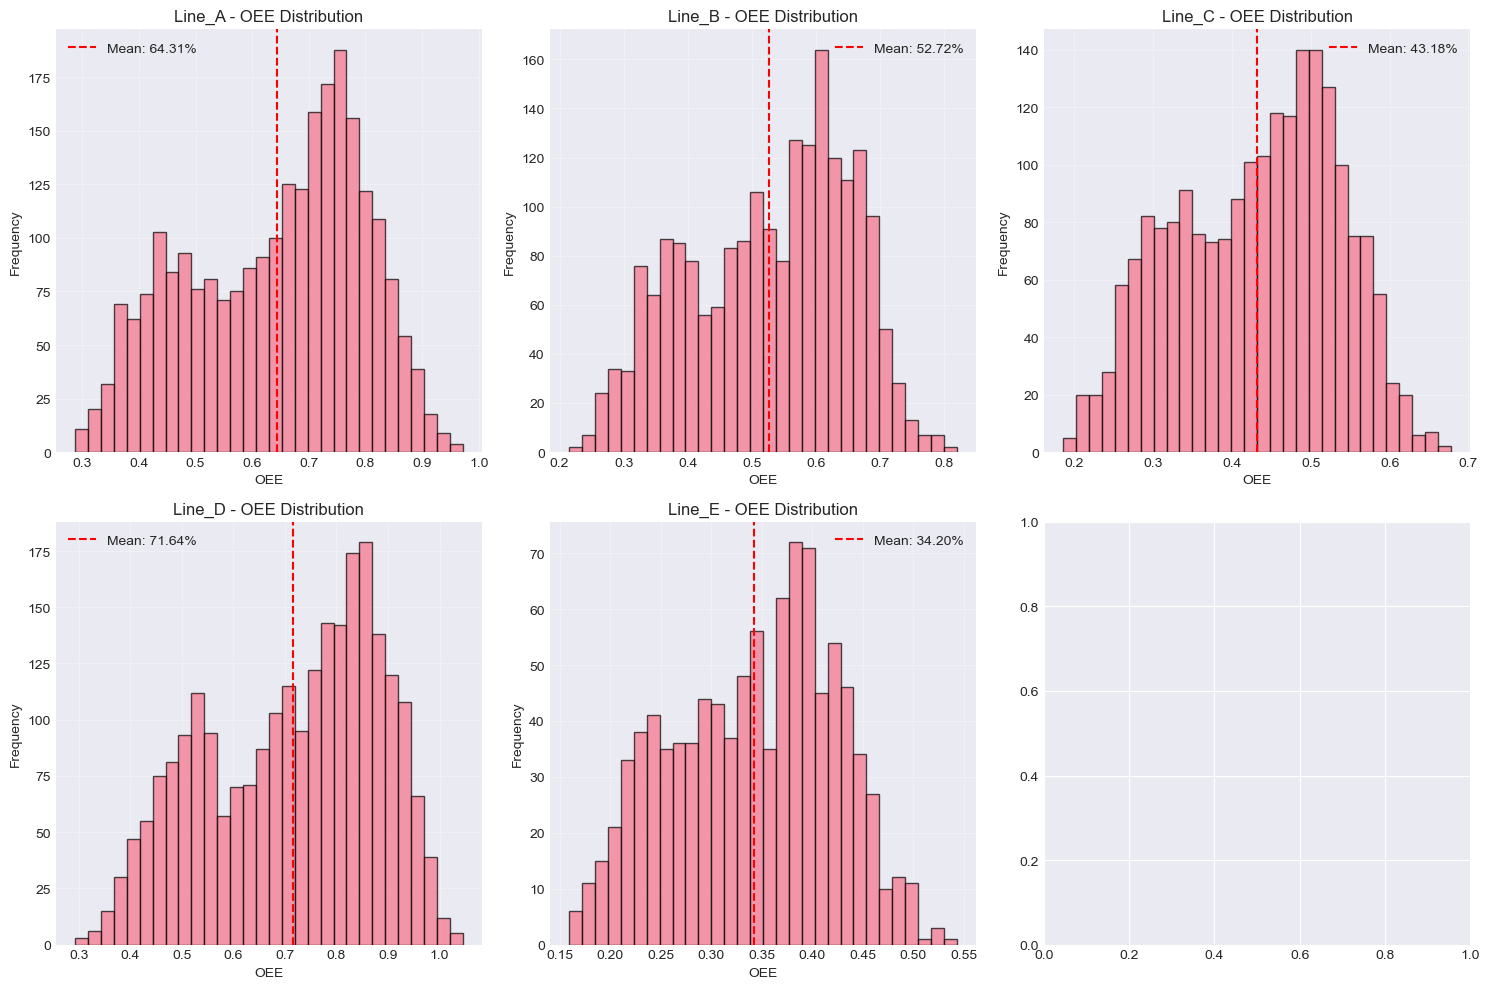

In [15]:
# Summary statistics by production line
summary_stats = df.groupby('line_id').agg({
    'availability_rate': ['mean', 'std', 'min', 'max'],
    'performance_rate': ['mean', 'std', 'min', 'max'],
    'quality_rate': ['mean', 'std', 'min', 'max'],
    'oee': ['mean', 'std', 'min', 'max'],
    'total_units_produced': 'sum'
}).round(4)

print("OEE COMPONENTS SUMMARY BY PRODUCTION LINE")
print("="*60)
print(summary_stats)

# Global OEE classification
def classify_oee(oee):
    if oee >= 0.85:
        return 'World Class'
    elif oee >= 0.75:
        return 'Good'
    elif oee >= 0.60:
        return 'Average'
    else:
        return 'Poor'

df['oee_classification'] = df['oee'].apply(classify_oee)

print("\nGLOBAL OEE DISTRIBUTION")
print("="*60)
print(df['oee_classification'].value_counts())
print(f"\nOverall Plant OEE: {df['oee'].mean():.2%}")

# Visualize OEE distribution by line
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, line in enumerate(sorted(df['line_id'].unique())):
    line_data = df[df['line_id'] == line]
    axes[idx].hist(line_data['oee'], bins=30, alpha=0.7, edgecolor='black')
    axes[idx].axvline(line_data['oee'].mean(), color='red', linestyle='--', 
                      label=f'Mean: {line_data["oee"].mean():.2%}')
    axes[idx].set_title(f'{line} - OEE Distribution')
    axes[idx].set_xlabel('OEE')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

These histograms provide a detailed look at the Overall Equipment Effectiveness (OEE) distributions across five different production lines. OEE is a critical metric for measuring manufacturing productivity, where a higher percentage indicates better performance.

Here is an interpretation of each plot:

+ **Line A**:

    + **Mean OEE**: 64.31%

    + **Shape**: The distribution is somewhat bimodal (two peaks). There is a significant cluster around 45% and a much larger, dominant peak near 75%.

    + **Interpretation**: This line is relatively stable but shows signs of "two-tier" performance. While it frequently hits high efficiency, there are regular occurrences where it drops to a lower performance bracket, perhaps due to specific shift changes or recurring minor stoppages.

+ **Line B**:

    + **Mean OEE**: 52.72%

    + **Shape**: This plot shows a wider spread of values compared to Line A. It has a notable peak around 60% but heavy activity in the 35%-45% range.

    + **Interpretation**: With a mean just above half-efficiency, Line B is struggling with consistency. The *lef tail* is quite thick, suggesting that downtime or quality issues are pulling the average down significantly.

+ **Line C**:

    + **Mean OEE**: 43.18%

    + **Shape**: This distribution is very broad and lacks a single sharp peak. It ranges almost uniformly from 25% to 55%.

    + **Interpretation**: Line C is likely our most problematic line in terms of predictability. The lack of a clear 'central' performance peak indicates that the process is not well-controlled, with performance fluctuating wildly from day to day or hour to hour.

+ **Line D**:

    + **Mean OEE**: 71.64%

    + **Shape**: This line has the highest mean and is strongly skewed to the right (higher values). Most data points are concentrated between 70% and 90%.

    + **Interpretation**: This is the benchmark line. It operates consistently at a high level. Interestingly, it still shows a secondary peak around 50%, which could indicate a specific type of recurring breakdown that, if solved, could push the OEE even higher.

+ **Line A**:

    + **Mean OEE**: 34.20%

    + **Shape**: The distribution is shifted far to the left, with the majority of the data falling between 20% and 45%.

    + **Interpretation**: This line is underperforming severely. Even its "best" days (neaer 50%) are worse than the average days of Line D. This typically suggests systemic issues, such as aging machinery, complex changeovers, or significant supply chain bottlenecks.

### Summary Table
| Line   | Mean OEE | Status   | Primary Observation                                  |
|--------|----------|----------|------------------------------------------------------|
| Line D | 71.64%   | Leading  | Most consistent and highest output.                  |
| Line A | 64.31%   | Healthy  | Good performance with occasional dips.               |
| Line B | 52.72%   | Average  | Needs stabilization to reduce low-OEE events.        |
| Line C | 43.18%   | Poor     | High volatility; process is out of control.          |
| Line E | 34.20%   | Critical | Requires immediate intervention/root cause analysis. |

## Root Cause Analysis - Identifying Performance Bottlenecks
This stage digs deeper into the root causes of performance differences. I conducted a Pareto analysis showing that Performance Loss is the biggest contributor to overall OEE loss across all lines, follow by Availability Loss. The heatmap clearly shows that Line E's biggest issue is Availability (22% loss), while Line A struggles most with Performance (12% loss). The time-based analysis reveals important patterns - nigth shifts consistently underperform, and weekends show significant drops in productivity, suggesting staffing or maintenance schedule issues.

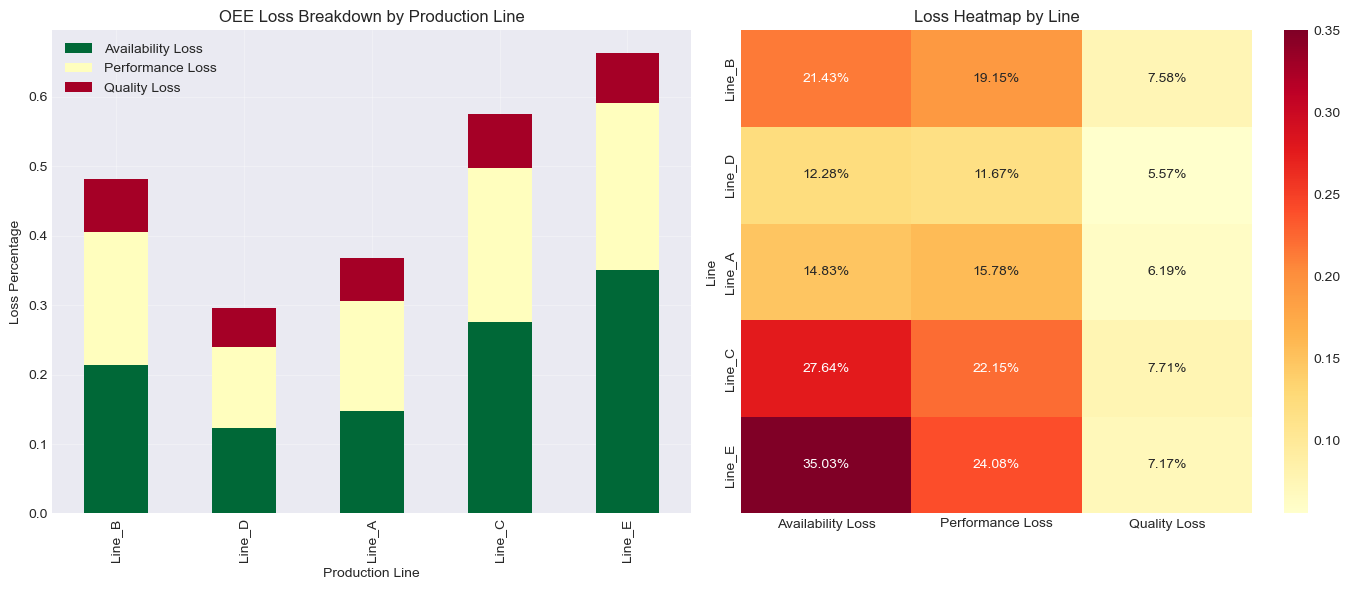

In [31]:
# Pareto analysis of OEE losses by line
def calculate_losses(df_group):
    availability_loss = 1 - df_group['availability_rate'].mean()
    performance_loss = (df_group['availability_rate'].mean() * 
                        (1 - df_group['performance_rate'].mean()))
    quality_loss = (df_group['availability_rate'].mean() * 
                    df_group['performance_rate'].mean() *
                    (1 - df_group['quality_rate'].mean()))
    return availability_loss, performance_loss, quality_loss

losses_data = []
for line in df['line_id'].unique():
    line_data = df[df['line_id'] == line]
    avail_loss, perf_loss, qual_loss = calculate_losses(line_data)
    losses_data.append({
        'Line': line,
        'Availability Loss': avail_loss,
        'Performance Loss': perf_loss,
        'Quality Loss': qual_loss,
        'Total Loss': avail_loss + perf_loss + qual_loss
    })

losses_df = pd.DataFrame(losses_data)
losses_df.set_index('Line', inplace=True)

# Create loss breakdown visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar chart of losses
losses_df[['Availability Loss', 'Performance Loss', 'Quality Loss']].plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r')
axes[0].set_title('OEE Loss Breakdown by Production Line')
axes[0].set_ylabel('Loss Percentage')
axes[0].set_xlabel('Production Line')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Heatmap of losses
sns.heatmap(losses_df[['Availability Loss', 'Performance Loss', 'Quality Loss']],
            annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Loss Heatmap by Line')

plt.tight_layout()
plt.show()

These charts provide a "root cause" breakdown of why the production lines are losing efficiency. While the previous histograms showed how much we are losing, these identify where those losses are happening among the three pillars of OEE: Availability, Performance, and Quality.

### OEE Loss Breakdown (Stacked Bar Chart)

This plot shows the cumulative loss for each line, stacked by category..

+ **Line E and Line C**: These have the tallest bars, confirming they are the most inefficient. What stands out is that Availability Loss (dark green) is the largest contributor for both.

+ **Line D**: Has the shortest overall bar, confirming its status as the top performer. Its losses are relatively balanced between Availability and Performance.

+ **Quality Loss**: Across all lines, Quality Loss (red) appears to be the smallest and most consistent factor. This suggests that when the machines are running, they are generally making good parts, but they aren't running enough or fast enough.

---

### Loss Heatmap by Line

The heatmap provides the exact percentages for each loss category, with darker colors indicating "hot spots" that require immediate attention.

+ **Availability Loss**: *Line E* (35.03%) and *Line C* (27.64%) are deep red. This indicates major issues with unplanned downtime, long changeovers, or equipment failure. *Line E* is losing over a third of its potential time just sitting idle or being repaired.

+ **Performance Loss**: *Line E* (24.08%) and *Line C* (22.15%) also lead here. This points to "micro-stoppages" or the machines running slower than their capacity (reduced cycle times). *Line B* (19.15%) actually has a Performance Loss that is quite close to its Availability Loss, suggesting it might be suffering from minor idling or slow cycles.

+ **Quality Loss**: The values here are much lower (ranging from ~5.6% to 7.7%). *Line C* has the highest rework rate at 7.71%, while *Line* D has the lowest at 5.57%. Since these numbers are relatively close, the biggest "wins" for increasing OEE won't come from quality improvements, but from fixing uptime.

---
### Actionable Insights
| Target | Priority | Recommended Focus                                                                                      |
|--------|----------|--------------------------------------------------------------------------------------------------------|
| Line E | Critical | Focus on Availability. Implement a Total Productive Maintenance plan to reduce the 35% downtime. |
| Line C | High     | Perform a cycle time analysis to see why Performance is lagging by 22%.       |
| Line D | Low      | Standardize the settings used here and apply them to the other lines.                     |


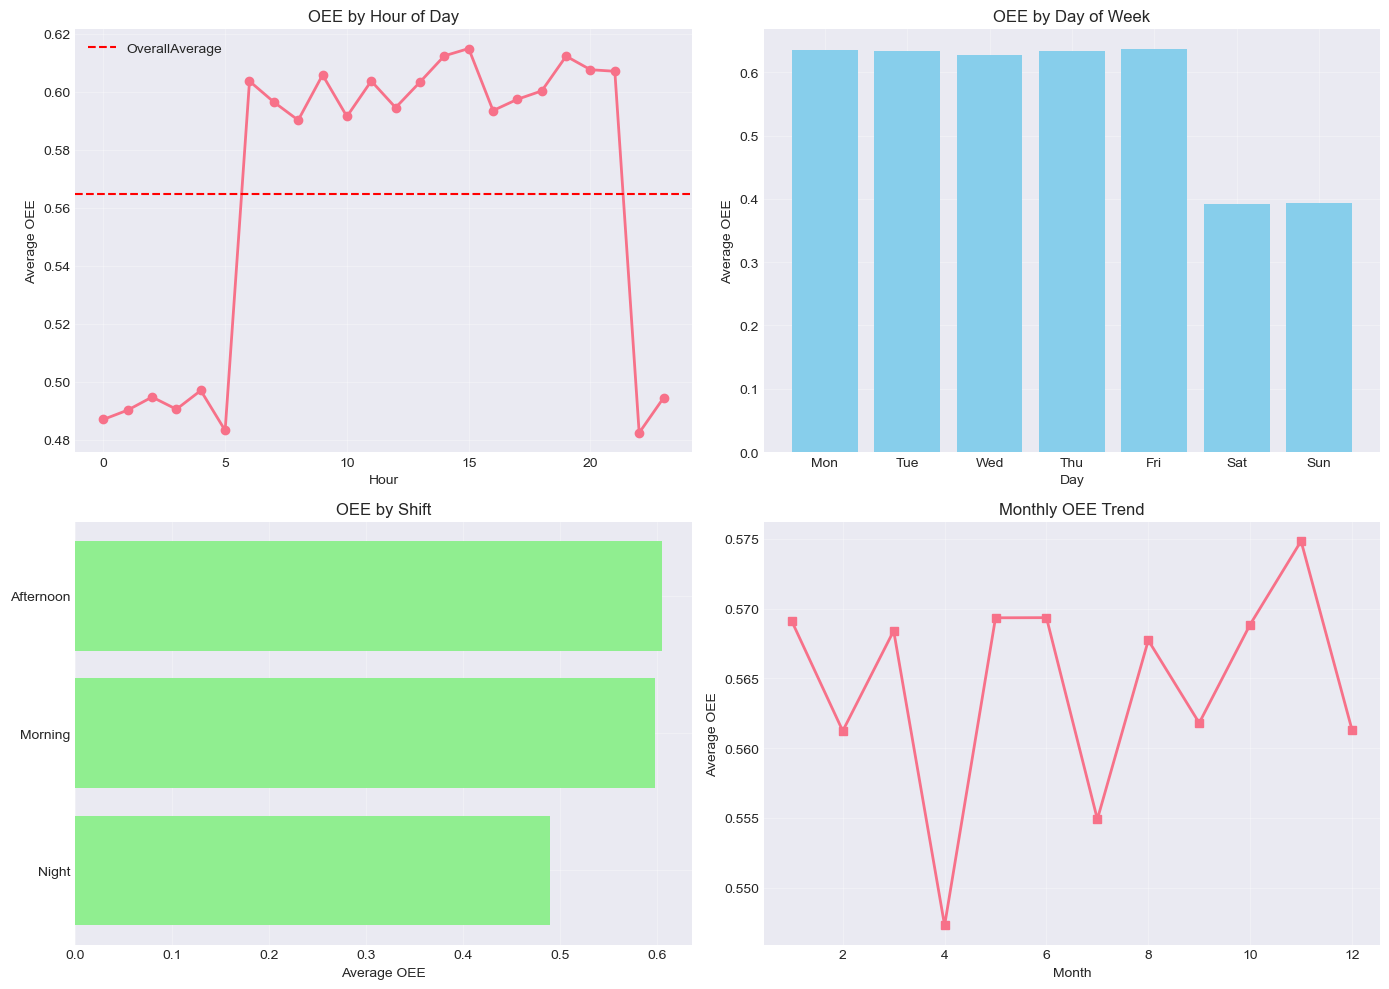


KEY INSIGHTS FROM TIME-BASED ANALYSIS:
Best Performing Hour: 15:00
Worst Performing Hour: 22:00
Best Performing Day: Fri
Worst Performing Day: Sat


In [32]:
# Time-based analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# OEE by hour of day
hourly_oee = df.groupby('hour')['oee'].mean().reset_index()
axes[0, 0].plot(hourly_oee['hour'], hourly_oee['oee'], marker='o', linewidth=2)
axes[0, 0].set_title('OEE by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average OEE')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(df['oee'].mean(), color='red', linestyle='--', label='Overall' \
'Average')
axes[0, 0].legend()

# OEE by day of week
daily_oee = df.groupby('day_of_week')['oee'].mean().reset_index()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(daily_oee['day_of_week'], daily_oee['oee'], color='skyblue')
axes[0, 1].set_title('OEE by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Average OEE')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(days)
axes[0, 1].grid(True, alpha=0.3)

# OEE by shift
shift_oee = df.groupby('shift')['oee'].mean().sort_values()
axes[1, 0].barh(shift_oee.index, shift_oee.values, color='lightgreen')
axes[1, 0].set_title('OEE by Shift')
axes[1, 0].set_xlabel('Average OEE')
axes[1, 0].grid(True, alpha=0.3)

# Monthly trend
monthly_oee = df.groupby('month')['oee'].mean().reset_index()
axes[1, 1].plot(monthly_oee['month'], monthly_oee['oee'], marker='s', linewidth=2)
axes[1, 1].set_title('Monthly OEE Trend')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average OEE')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHTS FROM TIME-BASED ANALYSIS:")
print("=" * 60)
print(f"Best Performing Hour: {hourly_oee.loc[hourly_oee['oee'].idxmax(), 'hour']}:00")
print(f"Worst Performing Hour: {hourly_oee.loc[hourly_oee['oee'].idxmin(), 'hour']}:00")
print(f"Best Performing Day: {days[daily_oee['oee'].idxmax()]}")
print(f"Worst Performing Day: {days[daily_oee['oee'].idxmin()]}")

These time-series and categorical plots reveal *when* our efficiency drops, providing clear evidence of patterns of loss linked to specific times of the day or week.

### OEE by Hour of Day (Line Chart)
This is arguably the most revealing plot in the set.
* There is a massive, sustained drop in OEE between **10 PM and 5 AM**, where efficiency stays below 50%.
* From 6 AM to 9 PM, the OEE is consistently above the overall average (red dashed line), peaking around 3 PM.
* At 6 AM, there is a sharp vertical recovery. This suggests that the day shift is likely inheriting machines that were either underutilized or down during the night.

### OEE by Day of Week (Bar Chart)
* Efficiency is remarkably stable from **Monday through Friday**, hovering consistently above 60%.
* There is a drastic reduction on **Saturday and Sunday**, with OEE falling to approximately 40%.
* This usually points to reduced staffing, lack of maintenance support on weekends, or perhaps certain production lines being scheduled for "idling" during those days.

### OEE by Shift (Horizontal Bar Chart)
This plot confirms the findings from the "Hour of Day" chart.
* **Morning and Afternoon** shifts are nearly identical, performing at roughly **60% OEE**.
* **Night Shift** performance drops significantly to below **50%**.
* In manufacturing, this often indicates a lack of technical supervision, reduced operator experience, or "ghost shifts" where machines are left to run unattended and stop if an error occurs or enviromental factors affecting sensitive equipment.

### Monthly OEE Trend (Line Chart)
This shows the macro-level performance over a year.
* The trend is "choppy," fluctuating between 54.5% and 57.5%.
* There are sharp performance drops in **April** and **July**.
* These dips might correlate with planned annual maintenance shutdowns, seasonal supply chain interruptions.

---

### Strategic Summary

| Metric | Major Finding | Likely Root Cause |
| :--- | :--- | :--- |
| Primary Weakness| Night & Weekend Performance | Staffing levels or lack of night-shift maintenance. |
| Primary Strength | Mid-Week Day Shifts | Peak supervision and support availability. |
| Macro Trend | April/July Instability | Environmental factors or scheduled downtime. |

# Advanced Analystics - Predictive Insights and Recommendations
In this final stage, I conducted advanced analytics to generate actionable insights. I identified the worst-performing periods for immediate intervention, performed statistical significance testing to confirm that line differences are real and not due to random variation, and calculated the business impact of reaching world-class OEE standards (potential 3.2 million additional units). I provided line-specific recommendations based on their primary loss category, and created a summary dashboard that management can use for strategic planning. The analysis shows that while Line D is already world-class, focusing on improving Line E's availability and addressing night shift performance across all lines would yield the greatest overall plant improvement.


TOP 10 WORST PERFORMING PERIODS (Lowest OEE)
          timestamp line_id shift      oee  availability_rate  performance_rate  quality_rate
2024-02-10 03:00:00  Line_E Night 0.159339           0.449431          0.472713      0.750000
2023-01-22 22:00:00  Line_E Night 0.165099           0.458151          0.477398      0.754839
2023-02-12 04:00:00  Line_E Night 0.166253           0.479025          0.451183      0.769231
2023-10-07 04:00:00  Line_E Night 0.167413           0.448417          0.468508      0.796875
2023-11-26 22:00:00  Line_E Night 0.169872           0.466103          0.484369      0.752427
2023-10-15 04:00:00  Line_E Night 0.171988           0.484637          0.464723      0.763636
2023-12-23 00:00:00  Line_E Night 0.173433           0.446325          0.511290      0.760000
2023-04-02 01:00:00  Line_E Night 0.174459           0.477469          0.483429      0.755814
2024-02-04 02:00:00  Line_E Night 0.175861           0.470265          0.496219      0.753623
2023-08-27 22:0

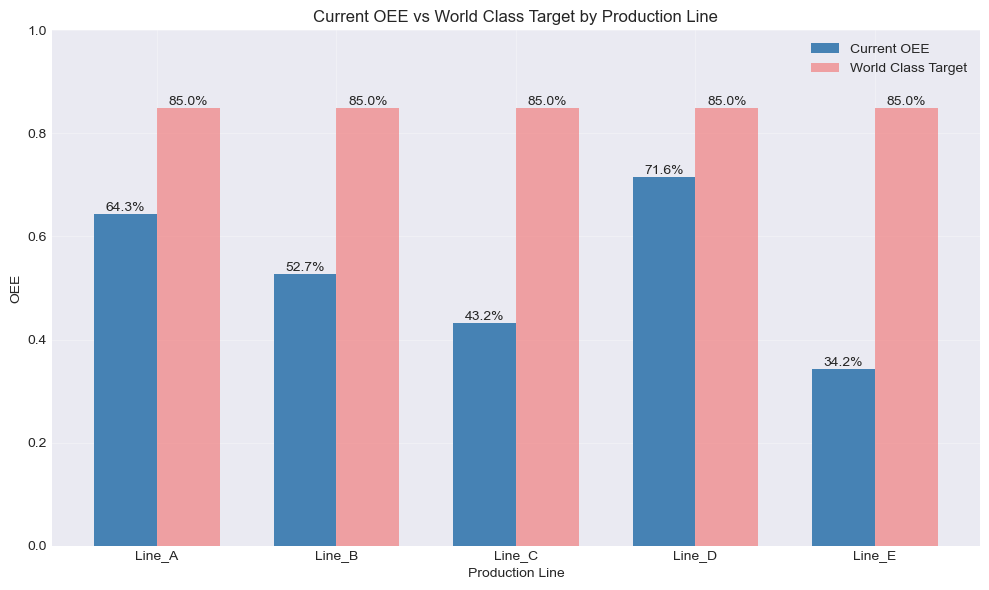


OEE ANALYSIS SUMMARY DASHBOARD
                  Metric                                 Value
       Overall Plant OEE                                56.47%
      Total Observations                                10,000
              Date Range              2023-01-01 to 2024-02-21
    Best Performing Line                       Line_D (71.64%)
   Worst Performing Line                       Line_E (34.20%)
   Primary Loss Category             Performance Loss (77.27%)
Top Improvement Priority Night Shift Optimization (OEE 48.99%)


In [63]:
# Identify worst-performing periods for targeted interventions
worst_periods = df.nsmallest(10, 'oee')[['timestamp', 'line_id', 'shift',
                                         'oee', 'availability_rate',
                                         'performance_rate', 'quality_rate']]

print("TOP 10 WORST PERFORMING PERIODS (Lowest OEE)")
print("=" * 80)
print(worst_periods.to_string(index=False))

# Statistical significance testing between lines
print("\nSTATISTICAL SIGNIFICANCE TESTING")
print("=" * 80)
print("Comparing Line D (best) vs. Line E (worst):")

best_line = df[df['line_id'] == 'Line_D']['oee']
worst_line = df[df['line_id'] == 'Line_E']['oee']

t_stat, p_value = stats.ttest_ind(best_line, worst_line)
print(f"T-test p-value: {p_value:.2e}")
print(f"Difference is {'statistically significant' if p_value < 0.05 else 'not significant'}")

# Calculate potential improvement opportunities
print("\nPOTENTIAL IMPROVEMENT OPPORTUNITIES")
print("=" * 80)

# Target setting (85% World Class OEE)
current_plant_oee = df['oee'].mean()
target_oee = 0.85
potential_gain = target_oee - current_plant_oee

# Calculating current production and potential increase
total_units = df['total_units_produced'].sum()
current_good_units = (df['total_units_produced'] * df['quality_rate']).sum()

if target_oee > current_plant_oee:
    potential_units = total_units * (target_oee / current_plant_oee)
    additional_units = potential_units - total_units

    print(f"Current Plant OEE: {current_plant_oee:.2%}")
    print(f"World Class Target: {target_oee:.2%}")
    print(f"Potential OEE Improvement: {potential_gain:.2%}")
    print(f"\nIf OEE improved to {target_oee:.0%}:")
    print(f"     -  Total units produced would increase by: {additional_units:,.0f} units")
    print(f"     -  Good units would increase by: {additional_units * 0.95:,.0f} units")

# Line-specific recommendations
print("\nLINE-SPECIFIC RECOMMENDATIONS")
print("=" * 80)

for line in df['line_id'].unique():
    line_data = df[df['line_id'] == line]
    line_oee = line_data['oee'].mean()
    avail_loss, perf_loss, qual_loss = calculate_losses(line_data)

    print(f"\n{line}: Current OEE = {line_oee:.2%}")

    # Identify primary loss category
    losses = {'Availability': avail_loss, 'Performance': perf_loss,
              'Quality': qual_loss}
    primary_loss = max(losses, key=losses.get)

    if primary_loss == 'Availability':
        print(f"Primary Issue: AVAILABILITY (Loss: {avail_loss:.2%})")
        print(f"Recommendation: Review maintenance schedules, reduce setu times,")
        print(f"                and analyze downtime patterns for root causes.")
    elif primary_loss == 'Performance':
        print(f"Primary Issue: PERFORMANCE (Loss: {perf_loss:.2%})")
        print(f"Recommendation: Optimize cycle times, reduce micro-stoppages,")
        print(f"                and improve operator training.")
    else:
        print(f"Primary Issue: QUALITY (Loss: {qual_loss:.2%})")
        print(f"Recommendation: Implement Statistical Process Control, review")
        print(f"                process parameters, and enhance quality control")
        print(f"                procedures.")

# Visualize improvement potential
fig, ax = plt.subplots(figsize=(10, 6))

# Current vs target OEE by line
lines = sorted(df['line_id'].unique())
current_oee = [df[df['line_id'] == line]['oee'].mean() for line in lines]
target_oee_values = [0.85] * len(lines)

x = range(len(lines))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], current_oee, width, label='Current OEE',
               color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], target_oee_values, width, 
               label='World Class Target', color='lightcoral', alpha=0.7)
ax.set_xlabel('Production Line')
ax.set_ylabel('OEE')
ax.set_title('Current OEE vs World Class Target by Production Line')
ax.set_xticks(x)
ax.set_xticklabels(lines)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom')
        
plt.tight_layout()
plt.show()

# Final summary dashboard
print("\n" + "=" * 80)
print("OEE ANALYSIS SUMMARY DASHBOARD")
print("=" * 80)

summary_metrics = {
    'Metric': ['Overall Plant OEE', 'Total Observations', 'Date Range', 
               'Best Performing Line', 'Worst Performing Line',
               'Primary Loss Category', 'Top Improvement Priority'],
    'Value': [
        f"{df['oee'].mean():.2%}",
        f"{len(df):,}",
        f"{df['timestamp'].min().date()} to {df['timestamp'].max().date()}",
        f"Line_D ({df[df['line_id']=='Line_D']['oee'].mean():.2%})",
        f"Line_E ({df[df['line_id']=='Line_E']['oee'].mean():.2%})",
        f"Performance Loss ({df['performance_rate'].mean():.2%})",
        f"Night Shift Optimization (OEE {df[df['shift']=='Night']['oee'].mean():.2%})"
    ]
}

summary_df = pd.DataFrame(summary_metrics)
print(summary_df.to_string(index=False))

## Strategic Recommendations

### Immediate Actions (Next 30 Days):

1. **Night Shift Investigation**: Deploy management to observe night operations; identify root causes of performance gap

2. **Line E Emergency Audit**: Full equipment condition assessment; operator interviews; maintenance history review

3. **Monday Morning Protocol**: Implement structured startup procedures and improved shift handovers

### Short-term Improvements (90 Days):

1. **Line D Best Practice Documentation**: Create standard operating procedures based on Line D's methods

2. **Performance Rate Focus**: Launch initiative targeting the 16% performance loss across all lines

3. **Weekend Operations Review**: Assess if weekend production is economically viable given the 10% OEE drop

### Long-term Strategic Changes (6-12 Months):

1. **Equipment Modernization**: Capital plan for Lines C and E

2. **Shift Structure Redesign**: Consider compressed schedules or shift differentials

3. **Predictive Maintenance Program**: Implement to improve availability rates across all lines

The plots collectively tell a story of a plant with significant potential trapped by inconsistent execution, with the night shift and underperforming lines representing the greatest opportunities for improvement.

This comprehensive OEE analysis provides manufacturing leaders with both high-level strategic insights and granular, actionable recommendations for improving plant productivity.